In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from torchvision.transforms import v2


In [2]:
import matplotlib.pyplot as plt
import math

%matplotlib inline

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CPU")

GPU: NVIDIA GeForce RTX 5060 Ti


In [4]:
data_train = pd.read_csv("digit-recognizer/train.csv", dtype = np.float32)
print("Number of training:",data_train.shape[0])

Number of training: 42000


In [5]:
data_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
X = data_train.drop("label", axis=1).values/255
y = data_train["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)
X_train= X_train.reshape(-1, 1, 28, 28)
X_test= X_test.reshape(-1, 1, 28, 28)

In [7]:
def plot_sample_images(X, y, ncols=5, num=25):
    num = int(min(num, len(y)))
    nrows = math.ceil(num / ncols)
    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(ncols, nrows))
    fig.subplots_adjust(hspace=0.8)
    for i, ax in enumerate(axes.flatten()):
        if i < num:
            ax.imshow(X.max()-X[i].reshape(28, 28), cmap="gray")
            ax.set_title(str(y[i]))
        ax.axis('off')
    plt.show()

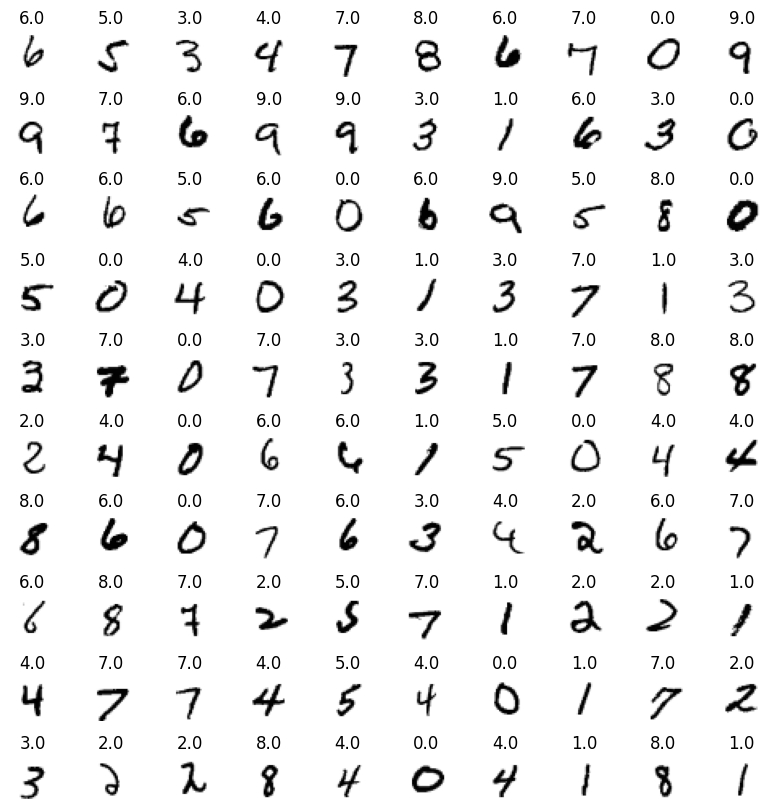

In [8]:
plot_sample_images(X_train, y_train, ncols=10, num=100)

In [9]:
BATCH_SIZE = 100

torch_X_train = torch.from_numpy(X_train)
torch_y_train = torch.from_numpy(y_train).type(torch.LongTensor)

torch_X_test = torch.from_numpy(X_test)
torch_y_test = torch.from_numpy(y_test).type(torch.LongTensor)

In [ ]:
# 1. Define the custom dataset
class MNISTDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        label = self.y[idx]
        
        # Reshape flat 784 tensor to 1x28x28 image
        if image.ndim == 1 or image.shape[-1] == 784:
            image = image.view(1, 28, 28)
            
        if self.transform:
            image = self.transform(image)
            
        return image, label

train_transforms = v2.Compose([
    v2.RandomRotation(degrees=5),     
    v2.RandomAffine(degrees=0, translate=(0.05, 0.05)), 
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])

# 3. Create the Datasets using the class
train_data = MNISTDataset(torch_X_train, torch_y_train, transform=train_transforms)
test_data = MNISTDataset(torch_X_test, torch_y_test, transform=test_transforms)

# 4. Create the DataLoaders (Notice shuffle=True for train, and num_workers added)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [11]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, stride=1, padding=0)
        self.cnn2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.fc0 = nn.Dropout(0.25)
        self.fc1 = nn.LazyLinear(10)

    def forward(self, x):
        out = torch.relu(self.cnn1(x))
        out = torch.relu(self.cnn2(out))
        out = out.view(out.size(0), -1)
        out = self.fc0(out)
        out = self.fc1(out)
        return out

# batch_size, epoch and iteration
batch_size = BATCH_SIZE

model = CNNModel()
model.to(device)
error = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor = 0.1)
num_epochs = 25



In [28]:
class CNNModel_slp(nn.Module):
    def __init__(self):
        super(CNNModel_slp, self).__init__()
        self.fc1 = nn.LazyLinear(10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc1(x)

# batch_size, epoch and iteration
batch_size = BATCH_SIZE

model_slp = CNNModel_slp()
model_slp.to(device)
error = nn.CrossEntropyLoss()
dummy_x = torch.randn(1, 1, 28, 28).to(device)
optimizer = torch.optim.AdamW(model_slp.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor = 0.1)
num_epochs = 25



In [12]:
# CNN model training
count = 0
loss_list = []
iteration_list = []
accuracy_list = []
for epoch in tqdm(range(num_epochs)):
    for i, (images, labels) in enumerate(train_loader):
        
        train = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()
        outputs = model(train)

        # Calculate softmax and ross entropy loss
        loss = error(outputs, labels)

        # Calculating gradients
        loss.backward()

        # Update parameters
        optimizer.step()

        count += 1

        if count % 50 == 0:
            # Calculate Accuracy
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:

                test = images.to(device)
                labels = labels.to(device)

                # Forward propagation
                outputs = model(test)

                # Get predictions from the maximum value
                predicted = torch.max(outputs, 1)[1]

                # Total number of labels
                total += len(labels)

                correct += (predicted  == labels).sum().item()

            accuracy = 100 * correct / float(total)

            # store loss and iteration
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)
        if count % 500 == 0:
            # Print Loss
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.item(), accuracy))
    scheduler.step(loss.item())

  4%|▍         | 1/25 [00:04<01:56,  4.87s/it]

Iteration: 500  Loss: 0.10862311720848083  Accuracy: 97.29761904761905 %


 12%|█▏        | 3/25 [00:15<01:51,  5.07s/it]

Iteration: 1000  Loss: 0.21252092719078064  Accuracy: 98.26190476190476 %


 16%|█▌        | 4/25 [00:19<01:43,  4.94s/it]

...

 88%|████████▊ | 22/25 [01:49<00:14,  4.80s/it]

Iteration: 7500  Loss: 0.09663417935371399  Accuracy: 99.07142857142857 %


 92%|█████████▏| 23/25 [01:54<00:09,  4.88s/it]

Iteration: 8000  Loss: 0.052045248448848724  Accuracy: 99.01190476190476 %


100%|██████████| 25/25 [02:04<00:00,  4.99s/it]


In [ ]:
# CNN model training
count = 0
loss_list = []
iteration_list = []
accuracy_list = []
for epoch in tqdm(range(num_epochs)):
    for i, (images, labels) in enumerate(train_loader):
        
        train = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()
        outputs = model_slp(train)

        # Calculate softmax and ross entropy loss
        loss = error(outputs, labels)

        # Calculating gradients
        loss.backward()

        # Update parameters
        optimizer.step()

        count += 1

        if count % 50 == 0:
            # Calculate Accuracy
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:

                test = images.to(device)
                labels = labels.to(device)

                # Forward propagation
                outputs = model_slp(test)

                # Get predictions from the maximum value
                predicted = torch.max(outputs, 1)[1]

                # Total number of labels
                total += len(labels)

                correct += (predicted  == labels).sum().item()

            accuracy = 100 * correct / float(total)

            # store loss and iteration
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)
        if count % 500 == 0:
            # Print Loss
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.item(), accuracy))
    scheduler.step(loss.item())

  4%|▍         | 1/25 [00:04<01:50,  4.62s/it]

Iteration: 500  Loss: 0.5367582440376282  Accuracy: 89.25 %


 12%|█▏        | 3/25 [00:14<01:44,  4.76s/it]

Iteration: 1000  Loss: 0.4690326750278473  Accuracy: 89.48809523809524 %


 16%|█▌        | 4/25 [00:18<01:38,  4.70s/it]

...

 88%|████████▊ | 22/25 [01:42<00:13,  4.54s/it]

Iteration: 7500  Loss: 0.42178329825401306  Accuracy: 90.52380952380952 %


 92%|█████████▏| 23/25 [01:46<00:09,  4.62s/it]

Iteration: 8000  Loss: 0.39654701948165894  Accuracy: 90.52380952380952 %


100%|██████████| 25/25 [01:56<00:00,  4.65s/it]


In [ ]:
import numpy as np

model.eval()
all_images = []
all_preds = []
all_trues = []
y_true_final = []
y_pred_final = []


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.max(outputs, 1)[1]
        
        all_images.append(images.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_trues.append(labels.cpu().numpy())

X_val = np.concatenate(all_images)
predicted_val = np.concatenate(all_preds)
true_val = np.concatenate(all_trues)

errors = (predicted_val != true_val)
total_errors = sum(errors)
print(f"Total Errors: {total_errors}")

errors_index = np.where(errors == True)[0]
true_value_labels = true_val[errors_index]
pred_value_labels = predicted_val[errors_index]
X_val_errors = X_val[errors_index]


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        
        outputs = model(images)
        # This is your y_pred
        predictions = torch.max(outputs, 1)[1]
        
        # Move to CPU and convert to list/numpy to save memory
        y_pred_final.extend(predictions.cpu().numpy())
        y_true_final.extend(labels.numpy())

print(f"Captured {len(y_pred_final)} predictions!")

Captured 8400 predictions!


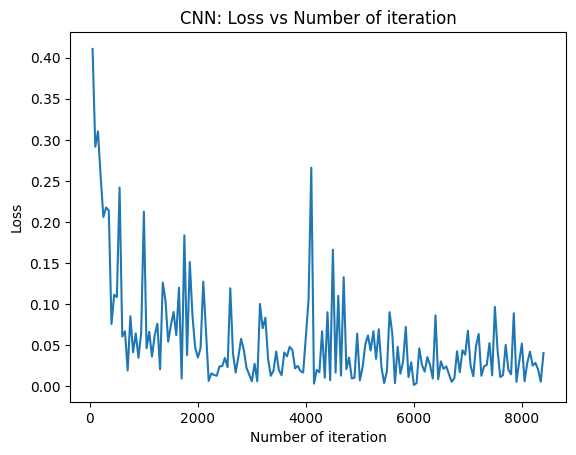

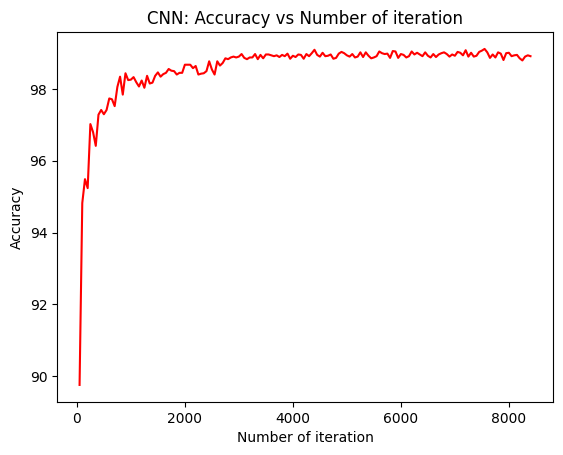

In [14]:
# visualization loss
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# visualization accuracy
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

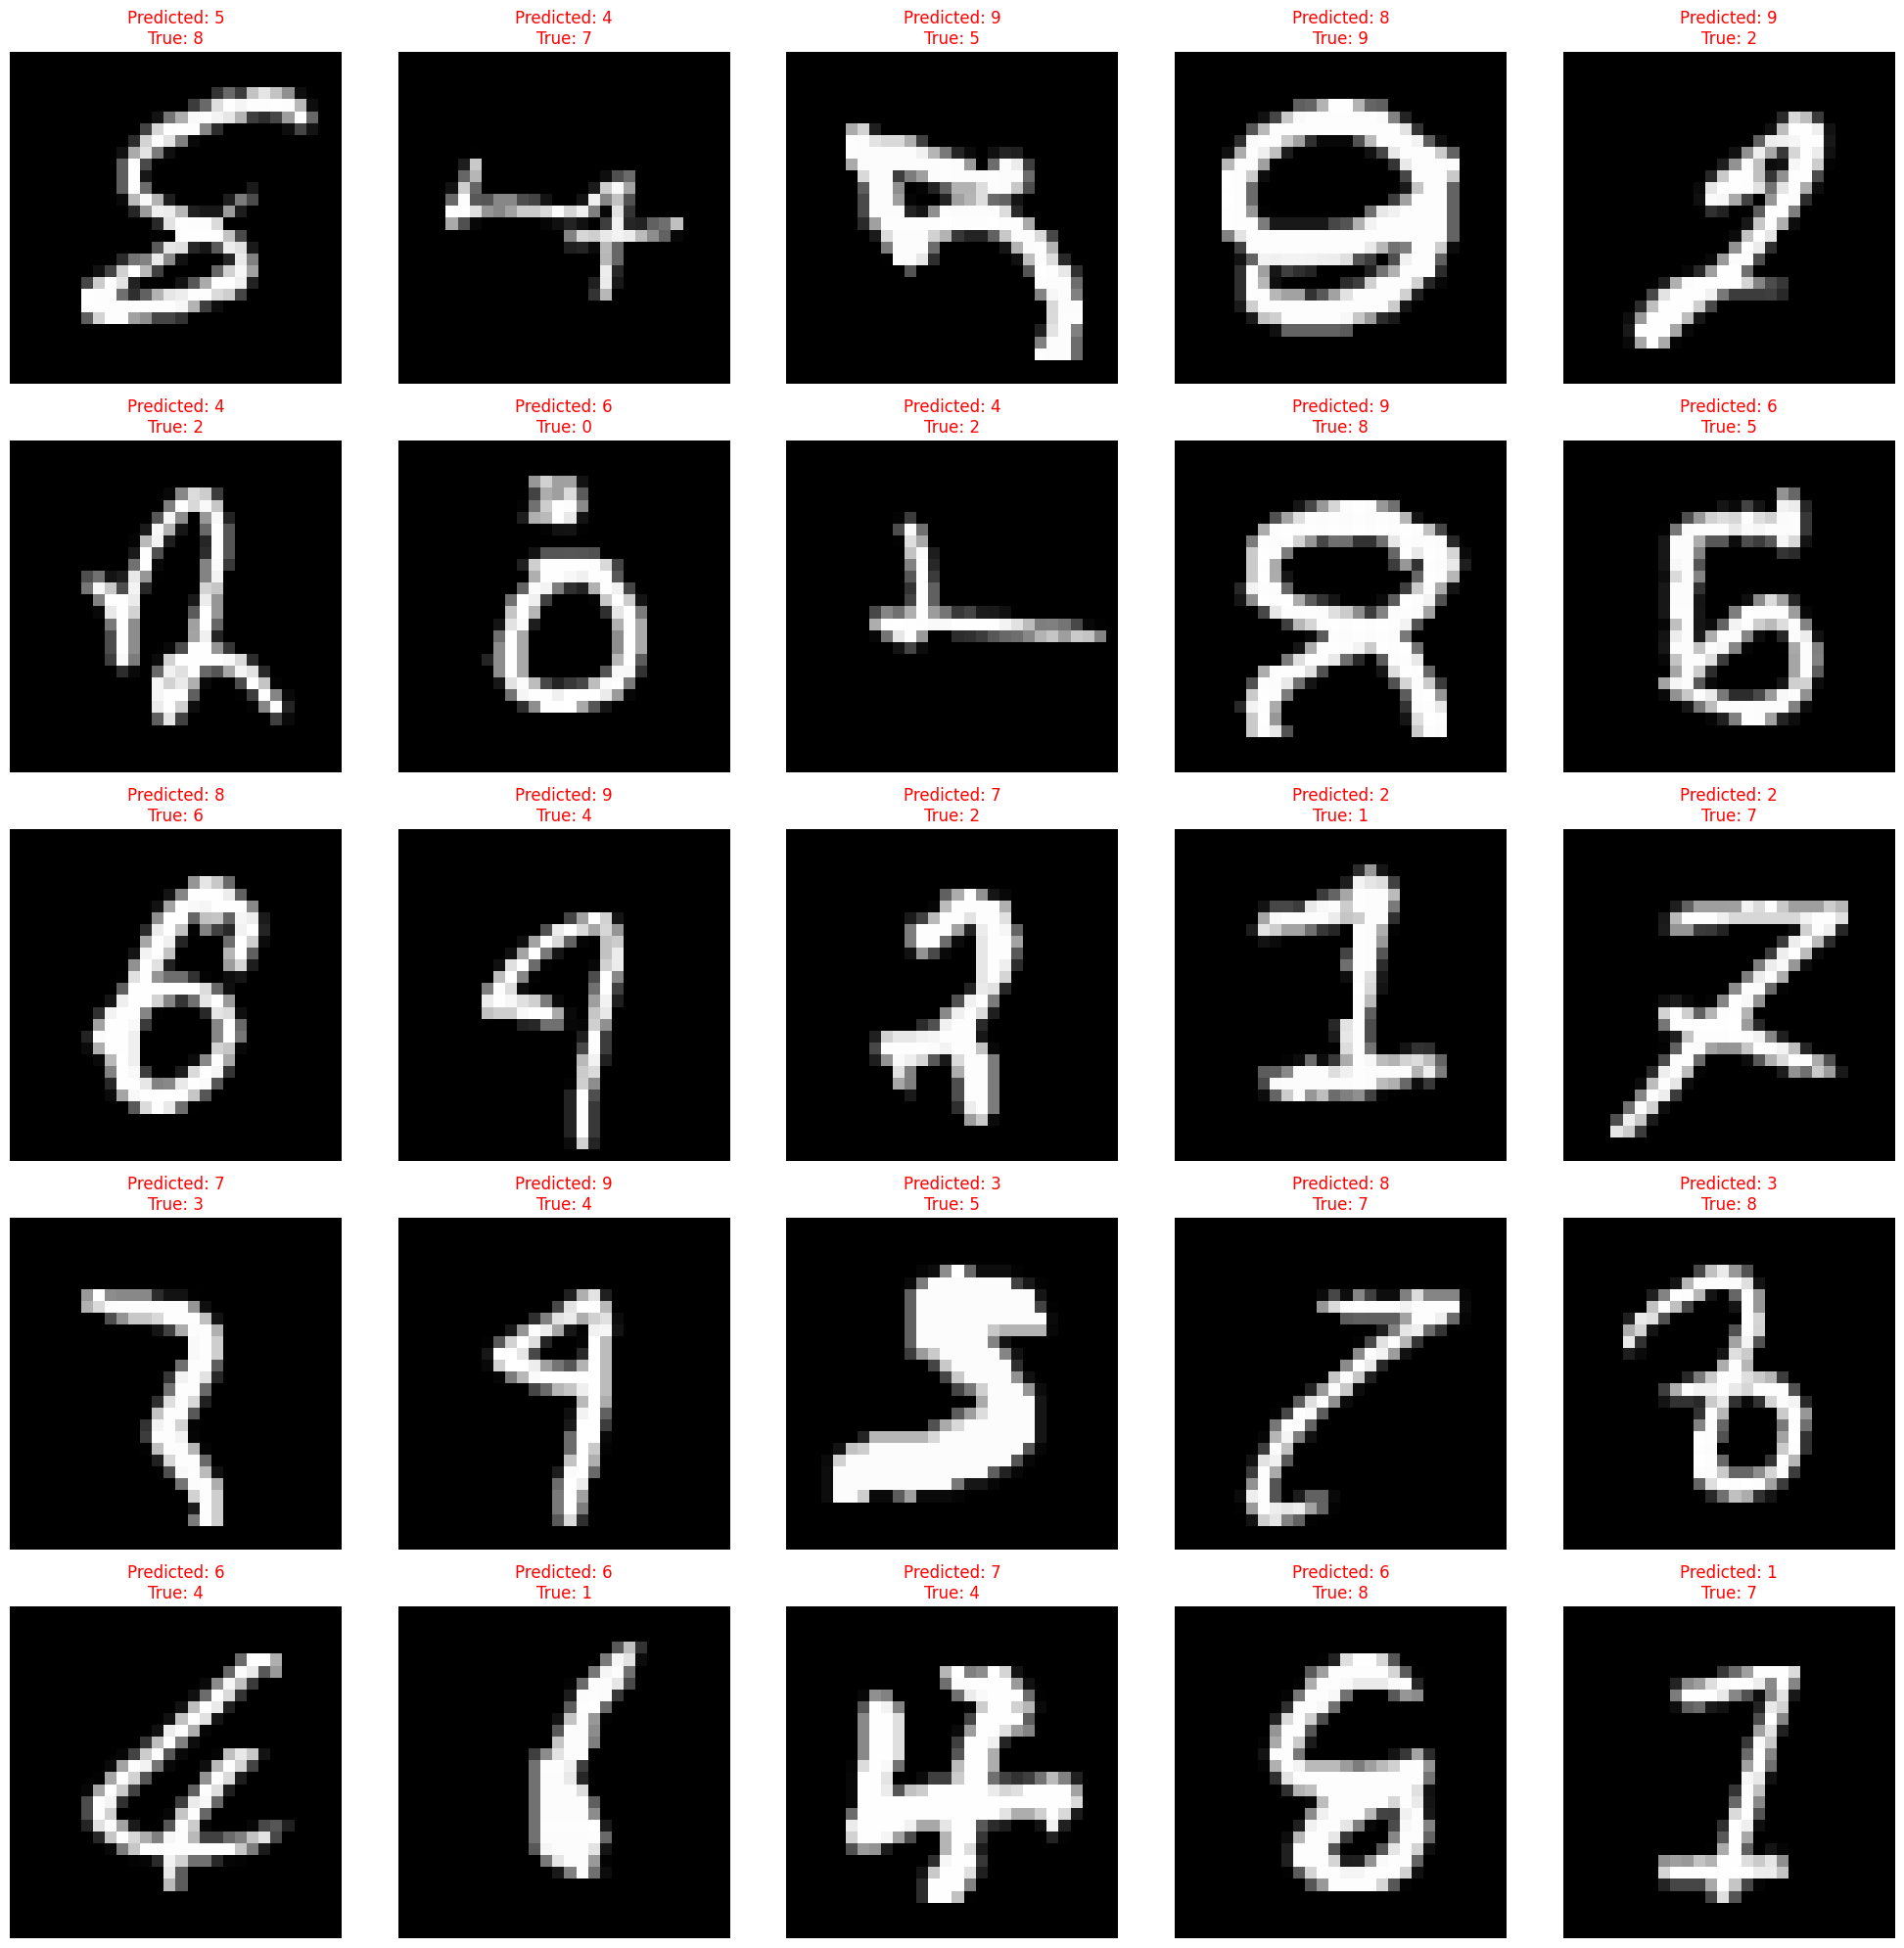

In [ ]:
import matplotlib.pyplot as plt

index = 0
n_rows = 5
n_cols = 5
fig, axis = plt.subplots(n_rows, n_cols, figsize=[20, 20])

for row in range(n_rows):
    for col in range(n_cols):
        if index < total_errors:
            img = X_val_errors[index].squeeze()
            
            axis[row, col].imshow(img, cmap='gray')
            axis[row, col].set_title(
                f"Predicted: {pred_value_labels[index]}\nTrue: {true_value_labels[index]}", 
                fontsize=12, 
                color='red'
            )
            axis[row, col].axis('off')
            index += 1

plt.tight_layout()
plt.show()